# 03 — TCGA Exploratory Data Analysis

This notebook explores the merged TCGA dataset produced by `02_tcga_data_loading.ipynb`, before any cleaning or feature selection is applied.

**Data sources:**
- TCGA PanCanAtlas expression (EB++ adjusted): https://gdc.cancer.gov/about-data/publications/pancanatlas
  - Direct download: https://api.gdc.cancer.gov/data/9a4679c3-855d-4055-8be9-3577ce10f66e
- MC3 somatic mutation calls: https://api.gdc.cancer.gov/data/1c8cfe5f-e52d-41ba-94da-f15ea1337efc

**Goals:**
- Understand the overall dataset structure and size
- Assess class balance for binary (WT vs mutant) and multi-class (mutation subtype) targets
- TP53 mRNA expression per mutation class with statistical tests
- Per-cancer-type TP53 mutation prevalence
- PCA and UMAP with all mutation classes labelled
- Motivate preprocessing decisions made in `04_tcga_preprocessing.ipynb`

> **Prerequisite**: run `02_tcga_data_loading.ipynb` first to generate `data/processed/tcga_merged_raw.csv.gz`

## Setup

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

PROCESSED_DIR = Path("../data/processed")

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# TCGA tissue source site → cancer type abbreviation (GDC TSS registry, subset)
# Full mapping: https://gdc.cancer.gov/resources-tcga-users/tcga-code-tables/tissue-source-site-codes
TSS_TO_CANCER = {
    'OR': 'ACC',  'OR': 'ACC', 'P6': 'ACC',
    'A2': 'BRCA', 'A7': 'BRCA', 'A8': 'BRCA', 'AC': 'BRCA', 'AN': 'BRCA',
    'AO': 'BRCA', 'AQ': 'BRCA', 'AR': 'BRCA', 'B6': 'BRCA', 'BH': 'BRCA',
    'C8': 'BRCA', 'D8': 'BRCA', 'E2': 'BRCA', 'E9': 'BRCA', 'EW': 'BRCA',
    'GI': 'BRCA', 'GM': 'BRCA', 'HN': 'BRCA', 'LD': 'BRCA', 'OL': 'BRCA',
    'OW': 'BRCA', 'PL': 'BRCA', 'S3': 'BRCA', 'UL': 'BRCA', 'WT': 'BRCA',
    'H9': 'BLCA', 'BT': 'BLCA', 'GC': 'BLCA', 'GU': 'BLCA', 'XF': 'BLCA',
    'YC': 'BLCA',
    'AB': 'STAD', 'BR': 'STAD', 'FP': 'STAD', 'HU': 'STAD', 'RD': 'STAD',
    '3C': 'STAD',
    '3X': 'CESC', 'C5': 'CESC', 'DS': 'CESC', 'EA': 'CESC', 'HM': 'CESC',
    'IR': 'CESC', 'MA': 'CESC', 'Q1': 'CESC', 'RL': 'CESC', 'UC': 'CESC',
    'VS': 'CESC', 'ZA': 'CESC',
    'SS': 'CHOL',
    '2Y': 'COAD', 'AA': 'COAD', 'AF': 'COAD', 'AG': 'COAD', 'AH': 'COAD',
    'AI': 'COAD', 'AZ': 'COAD', 'D5': 'COAD', 'DM': 'COAD', 'F4': 'COAD',
    'G4': 'COAD', 'QG': 'COAD', 'SL': 'COAD', 'T9': 'COAD',
    '4D': 'DLBC',
    '2Z': 'ESCA', 'LN': 'ESCA', 'Q9': 'ESCA', 'VR': 'ESCA',
    'OK': 'GBM',  'O2': 'GBM',  'O6': 'GBM',  'O8': 'GBM',
    '12': 'GBM',  '14': 'GBM',  '15': 'GBM',  '16': 'GBM',
    '02': 'GBM',  '06': 'GBM',  '08': 'GBM',  '19': 'GBM',
    '32': 'GBM',  'DU': 'GBM',  'FG': 'GBM',  'HT': 'GBM',  'IK': 'GBM',
    'P5': 'GBM',  'QH': 'GBM',  'RR': 'GBM',  'S9': 'GBM',  'TM': 'GBM',
    'W9': 'GBM',  'YW': 'GBM',  'ZH': 'GBM',
    'CZ': 'HNSC', 'HD': 'HNSC', 'IQ': 'HNSC', 'MT': 'HNSC', 'MX': 'HNSC',
    'P3': 'HNSC', 'TN': 'HNSC', 'UF': 'HNSC',
    'A3': 'KIRC', 'AK': 'KIRC', 'AL': 'KIRC', 'AS': 'KIRC', 'B0': 'KIRC',
    'B2': 'KIRC', 'B4': 'KIRC', 'B8': 'KIRC', 'BP': 'KIRC', 'CJ': 'KIRC',
    'CW': 'KIRC', 'DV': 'KIRC', 'EU': 'KIRC', 'F1': 'KIRC', 'F9': 'KIRC',
    'G6': 'KIRC', 'HE': 'KIRC', 'J7': 'KIRC', 'MM': 'KIRC', 'MX': 'KIRC',
    'T7': 'KIRC',
    'B9': 'KIRP', 'BQ': 'KIRP', 'BY': 'KIRP', 'EV': 'KIRP', 'HK': 'KIRP',
    'GL': 'KICH',
    'A5': 'LAML', 'AB': 'LAML',
    '01': 'LGG', 'CS': 'LGG',  'DH': 'LGG',  'E1': 'LGG',  'FH': 'LGG',
    'HW': 'LGG', 'P4': 'LGG',  'QH': 'LGG',  'S9': 'LGG',  'TQ': 'LGG',
    'VM': 'LGG', 'WY': 'LGG',
    'C4': 'LIHC', 'DD': 'LIHC', 'ES': 'LIHC', 'FV': 'LIHC', 'G3': 'LIHC',
    'LP': 'LIHC', 'MI': 'LIHC', 'RC': 'LIHC', 'ZH': 'LIHC',
    '4B': 'LUAD', '38': 'LUAD', '44': 'LUAD', '49': 'LUAD', '50': 'LUAD',
    '55': 'LUAD', '64': 'LUAD', '67': 'LUAD', '69': 'LUAD', '73': 'LUAD',
    '86': 'LUAD', 'CK': 'LUAD', 'J8': 'LUAD', 'L4': 'LUAD', 'MG': 'LUAD',
    'MP': 'LUAD', 'N7': 'LUAD', 'NJ': 'LUAD', 'O1': 'LUAD', 'OY': 'LUAD',
    'PK': 'LUAD', 'TG': 'LUAD', 'UC': 'LUAD', 'XC': 'LUAD',
    '18': 'LUSC', '22': 'LUSC', '33': 'LUSC', '34': 'LUSC', '37': 'LUSC',
    '43': 'LUSC', '56': 'LUSC', '58': 'LUSC', '60': 'LUSC', '62': 'LUSC',
    '65': 'LUSC', '66': 'LUSC', '68': 'LUSC', '71': 'LUSC', '77': 'LUSC',
    '85': 'LUSC', 'J2': 'LUSC', 'NK': 'LUSC',
    'AC': 'MESO', 'MK': 'MESO',
    'AF': 'OV', 'AO': 'OV',  'AX': 'OV',  'AY': 'OV',  'AZ': 'OV',
    'E6': 'OV',  'E7': 'OV',  'E8': 'OV',  'EO': 'OV',  'EW': 'OV',
    'FI': 'OV',  'FK': 'OV',  'FM': 'OV',  'G9': 'OV',  'GE': 'OV',
    'IJ': 'OV',  'IO': 'OV',  'J4': 'OV',  'K4': 'OV',  'L1': 'OV',
    'NC': 'OV',  'PG': 'OV',  'PH': 'OV',  'WR': 'OV',
    '20': 'PAAD', '2L': 'PAAD', 'F2': 'PAAD', 'HV': 'PAAD', 'IB': 'PAAD',
    'LB': 'PAAD', 'M8': 'PAAD', 'OE': 'PAAD', 'Q9': 'PAAD', 'RB': 'PAAD',
    'S4': 'PAAD', 'XD': 'PAAD', 'YB': 'PAAD', 'YH': 'PAAD',
    '5U': 'PRAD', 'CH': 'PRAD', 'EJ': 'PRAD', 'FC': 'PRAD', 'G7': 'PRAD',
    'HC': 'PRAD', 'KK': 'PRAD', 'M7': 'PRAD', 'PD': 'PRAD', 'V1': 'PRAD',
    'XJ': 'PRAD', 'YJ': 'PRAD', 'ZG': 'PRAD',
    '2F': 'READ', 'DC': 'READ', 'G5': 'READ',
    'GD': 'SARC', 'MV': 'SARC', 'Q3': 'SARC', 'WK': 'SARC', 'X6': 'SARC',
    'XP': 'SARC',
    '3N': 'SKCM', '3S': 'SKCM', 'BF': 'SKCM', 'D3': 'SKCM', 'D9': 'SKCM',
    'DA': 'SKCM', 'EE': 'SKCM', 'ER': 'SKCM', 'FS': 'SKCM', 'GF': 'SKCM',
    'GN': 'SKCM', 'HR': 'SKCM', 'IH': 'SKCM',
    '2W': 'THCA', '3Y': 'THCA', 'AJ': 'THCA', 'BJ': 'THCA', 'DE': 'THCA',
    'DO': 'THCA', 'ET': 'THCA', 'EZ': 'THCA', 'FL': 'THCA', 'FY': 'THCA',
    'J8': 'THCA', 'QR': 'THCA',
    'BI': 'THYM', 'LC': 'THYM', 'XR': 'THYM',
    '2V': 'UCEC', 'AJ': 'UCEC', 'AP': 'UCEC', 'AW': 'UCEC', 'B5': 'UCEC',
    'BI': 'UCEC', 'BS': 'UCEC', 'D1': 'UCEC', 'EO': 'UCEC', 'FI': 'UCEC',
    'GH': 'UCEC', 'IK': 'UCEC', 'QS': 'UCEC',
    'ES': 'UCS',
    'EI': 'UVM',
}

In [ ]:
DATA_FILE = PROCESSED_DIR / "tcga_merged_raw.csv.gz"
assert DATA_FILE.exists(), f"Missing: {DATA_FILE} — run notebook 02 first."

print("Loading merged dataset...")
df = pd.read_csv(DATA_FILE, index_col=0, low_memory=False)

# Normalise binary label column name (may be 'Mutated' or 'tp53_binary')
if 'Mutated' in df.columns and 'tp53_binary' not in df.columns:
    df = df.rename(columns={'Mutated': 'tp53_binary'})

LABEL_COLS = ['tp53_binary', 'Variant_Classification']
gene_cols  = [c for c in df.columns if c not in LABEL_COLS]

X      = df[gene_cols]
y_bin  = df['tp53_binary'].astype(int)
y_multi = df['Variant_Classification']

# Apply updated class map (matches notebook 04 merging rules)
CLASS_MAP = {
    'Missense_Mutation':      'Missense',
    'Frame_Shift_Del':        'Frameshift',
    'Frame_Shift_Ins':        'Frameshift',
    'Nonsense_Mutation':      'Nonsense',
    'Splice_Site':            'Splice',
    'In_Frame_Del':           'InFrame',
    'In_Frame_Ins':           'InFrame',
    'Translation_Start_Site': 'Nonsense',
    'Silent':                 'Silent',   # labelled separately for transparency
    'WT':                     'WT',
}
y_class = y_multi.map(CLASS_MAP).fillna('Other_noncoding')

# Derive cancer type from TCGA barcode (format: TCGA-{TSS}-{patient})
df['cancer_type'] = df.index.str.split('-').str[1].map(TSS_TO_CANCER).fillna('Unknown')

print(f"Shape: {df.shape[0]:,} patients × {df.shape[1]:,} columns")
print(f"  Gene columns  : {len(gene_cols):,}")
print(f"  Label columns : {len(LABEL_COLS)}")
print(f"  Cancer types mapped: {(df['cancer_type'] != 'Unknown').sum():,} / {len(df):,}")

---

## 1. Dataset overview

In [3]:
print("=== Data types ===")
print(df.dtypes.value_counts().to_string())
print()
print("=== Missing values ===")
total_missing = df.isnull().sum().sum()
print(f"Total NaN cells: {total_missing:,}")
if total_missing > 0:
    cols_with_nan = df.isnull().sum()
    cols_with_nan = cols_with_nan[cols_with_nan > 0]
    print(f"Columns with any NaN: {len(cols_with_nan):,}")
    print(cols_with_nan.sort_values(ascending=False).head(20).to_string())

=== Data types ===
float64    20501
int64          1
str            1

=== Missing values ===
Total NaN cells: 4,069,730
Columns with any NaN: 3,338
ZSWIM2        1690
HES3          1690
HPVC1         1690
HNRNPCL1      1690
HMGB4         1690
HIST1H4G      1690
HIST1H2BA     1690
HIST1H2AA     1690
HIGD1C        1690
SLC17A1       1690
SLC17A2       1690
H2BFM         1690
HDGFL1        1690
SLC22A24      1690
HBII-52-46    1690
HBII-52-45    1690
HBII-52-28    1690
HBII-52-27    1690
HBII-52-24    1690
HBBP1         1690


---

## 2. Class balance

### 2a. Binary target: TP53 mutated vs. wild-type

Mutated
Wild-type    6744
Mutated      3131

Mutation rate: 31.7%


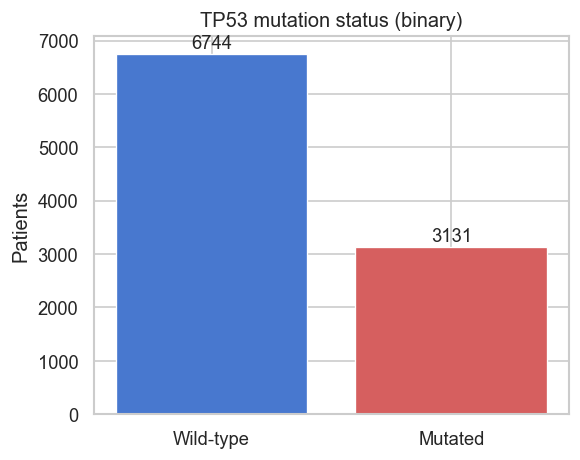

In [4]:
counts_bin = y_bin.value_counts().rename({0: 'Wild-type', 1: 'Mutated'})
print(counts_bin.to_string())
print(f"\nMutation rate: {counts_bin['Mutated'] / counts_bin.sum() * 100:.1f}%")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(counts_bin.index, counts_bin.values, color=['#4878CF', '#D65F5F'], edgecolor='white', linewidth=0.8)
for i, v in enumerate(counts_bin.values):
    ax.text(i, v + 30, str(v), ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Patients')
ax.set_title('TP53 mutation status (binary)')
plt.tight_layout()
plt.show()

### 2b. Multi-class target: mutation type breakdown

Variant_Classification
WT                   6744
Missense_Mutation    1949
Nonsense_Mutation     452
Frame_Shift_Del       298
Splice_Site           215
Frame_Shift_Ins        96
In_Frame_Del           59
Silent                 43
In_Frame_Ins            9
Intron                  5
3'UTR                   4
5'UTR                   1


/var/folders/bp/dy6w12yn1bgg5xmsdj1c8qg80000gn/T/ipykernel_93848/3051150302.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts_multi.index, rotation=30, ha='right')


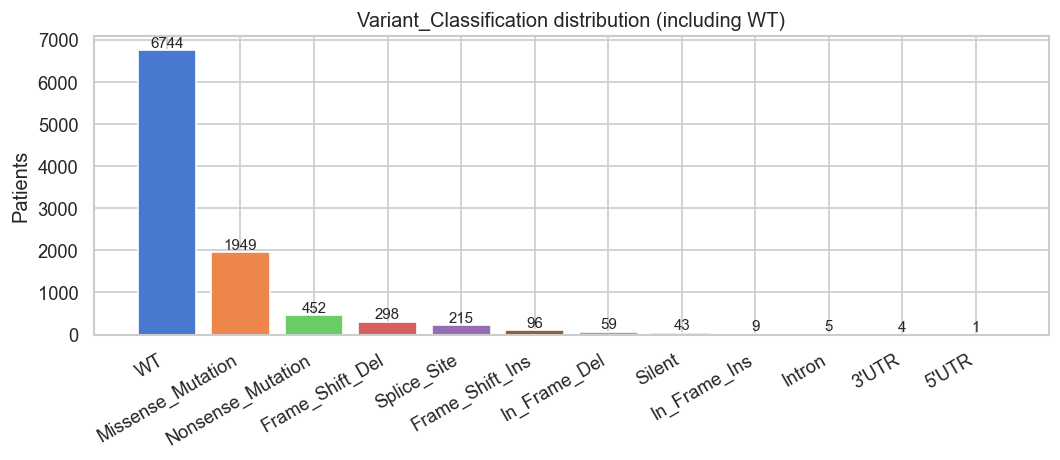

In [5]:
counts_multi = y_multi.value_counts()
print(counts_multi.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(counts_multi.index, counts_multi.values,
              color=sns.color_palette('muted', len(counts_multi)), edgecolor='white')
for bar, val in zip(bars, counts_multi.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            str(val), ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Patients')
ax.set_title('Variant_Classification distribution (including WT)')
ax.set_xticklabels(counts_multi.index, rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Fine-grained mutation classes (after merging del+ins variants)
class_order = ['WT', 'Missense', 'Nonsense', 'Frameshift', 'Splice', 'InFrame', 'Silent', 'Other_noncoding']
class_palette = {
    'WT':             '#4878CF',
    'Missense':       '#D65F5F',
    'Nonsense':       '#E58606',
    'Frameshift':     '#52BCA3',
    'Splice':         '#99C945',
    'InFrame':        '#CC61B0',
    'Silent':         '#BBBBBB',
    'Other_noncoding':'#DDDDDD',
}
counts_class = y_class.value_counts().reindex(class_order, fill_value=0)
print("Fine-grained class distribution:")
print(counts_class.to_string())

# Mutant-only breakdown
mut_classes = [c for c in class_order if c not in ('WT', 'Silent', 'Other_noncoding')]
counts_mut = counts_class.reindex(mut_classes, fill_value=0)
print(f"\nMutation-type breakdown (mutant only, excluding Silent/non-coding):")
print(counts_mut.to_string())
print(f"\nFractional breakdown among mutants:")
for c, n in counts_mut.items():
    print(f"  {c:<12s}: {n:5d} ({n/counts_mut.sum()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All classes including WT
colors_all = [class_palette.get(c, '#AAAAAA') for c in counts_class.index]
bars = axes[0].bar(counts_class.index, counts_class.values, color=colors_all, edgecolor='white')
for bar, val in zip(bars, counts_class.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(val), ha='center', va='bottom', fontsize=8)
axes[0].set_title('TP53 class distribution (all samples)')
axes[0].set_ylabel('Patients')
axes[0].set_xticklabels(counts_class.index, rotation=30, ha='right')

# Mutant-only, excluding Silent and non-coding (to be modelled in Task 2)
colors_mut = [class_palette.get(c, '#AAAAAA') for c in counts_mut.index]
bars2 = axes[1].bar(counts_mut.index, counts_mut.values, color=colors_mut, edgecolor='white')
for bar, val in zip(bars2, counts_mut.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f"{val}\n({val/counts_mut.sum()*100:.0f}%)", ha='center', va='bottom', fontsize=8)
axes[1].set_title('Mutation subtypes (Task 2 classes, Silent/non-coding excluded)')
axes[1].set_ylabel('Patients')
axes[1].set_xticklabels(counts_mut.index, rotation=20, ha='right')

plt.suptitle('TP53 mutation class distribution — TCGA PanCan (n=9,875)', y=1.01)
plt.tight_layout()
plt.show()

### 2c. TP53 mutation prevalence by cancer type

TP53 mutation rates vary dramatically across cancer types — from ~10% in thyroid cancer to ~96% in high-grade serous ovarian cancer. Controlling for cancer type is important because expression profiles are dominated by tissue-of-origin effects.

In [ ]:
ct_df = df[['cancer_type', 'tp53_binary']].copy()
known = ct_df[ct_df['cancer_type'] != 'Unknown']
print(f"Patients with mapped cancer type: {len(known):,} / {len(ct_df):,}")

if len(known) > 0:
    ct_stats = (known.groupby('cancer_type')['tp53_binary']
                .agg(n_patients='count', n_mutated='sum')
                .assign(mut_rate=lambda d: d['n_mutated'] / d['n_patients'])
                .sort_values('mut_rate', ascending=False)
                .reset_index())

    print(f"\nCancer types found: {len(ct_stats)}")
    print(ct_stats.to_string(index=False))

    fig, ax = plt.subplots(figsize=(14, 5))
    colors_ct = ['#D65F5F' if r > 0.5 else '#4878CF' for r in ct_stats['mut_rate']]
    bars = ax.bar(ct_stats['cancer_type'], ct_stats['mut_rate'] * 100,
                  color=colors_ct, edgecolor='white')
    for bar, n in zip(bars, ct_stats['n_patients']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"n={n}", ha='center', va='bottom', fontsize=7, rotation=90)
    ax.axhline(y_bin.mean() * 100, linestyle='--', color='black', linewidth=1,
               label=f'PanCan mean ({y_bin.mean()*100:.1f}%)')
    ax.set_ylabel('TP53 mutation rate (%)')
    ax.set_title('TP53 mutation prevalence by cancer type (TCGA PanCan)')
    ax.set_xticklabels(ct_stats['cancer_type'], rotation=45, ha='right', fontsize=9)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No cancer type mapping available — download TCGA clinical data for full mapping.")

---

## 3. Expression data quality

### 3a. Global value distribution

The expression values are raw RSEM units — not log-transformed. The distribution is expected to be highly right-skewed (most genes are lowly expressed).

In [7]:
# Sample 2M random values for the histogram (full matrix is ~2×10^8 values)
rng = np.random.default_rng(42)
flat_sample = rng.choice(X.values.ravel(), size=min(2_000_000, X.size), replace=False)

print("Global expression statistics (sampled):")
print(pd.Series(flat_sample).describe())

Global expression statistics (sampled):
count    1.959684e+06
mean     1.000784e+03
std      6.699992e+03
min     -9.912106e-01
25%      6.341199e+00
50%      2.006217e+02
75%      8.446402e+02
max      3.298360e+06
dtype: float64


/var/folders/bp/dy6w12yn1bgg5xmsdj1c8qg80000gn/T/ipykernel_93848/1620443244.py:18: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/elizabeth/opt/anaconda3/envs/tp53-predictor/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


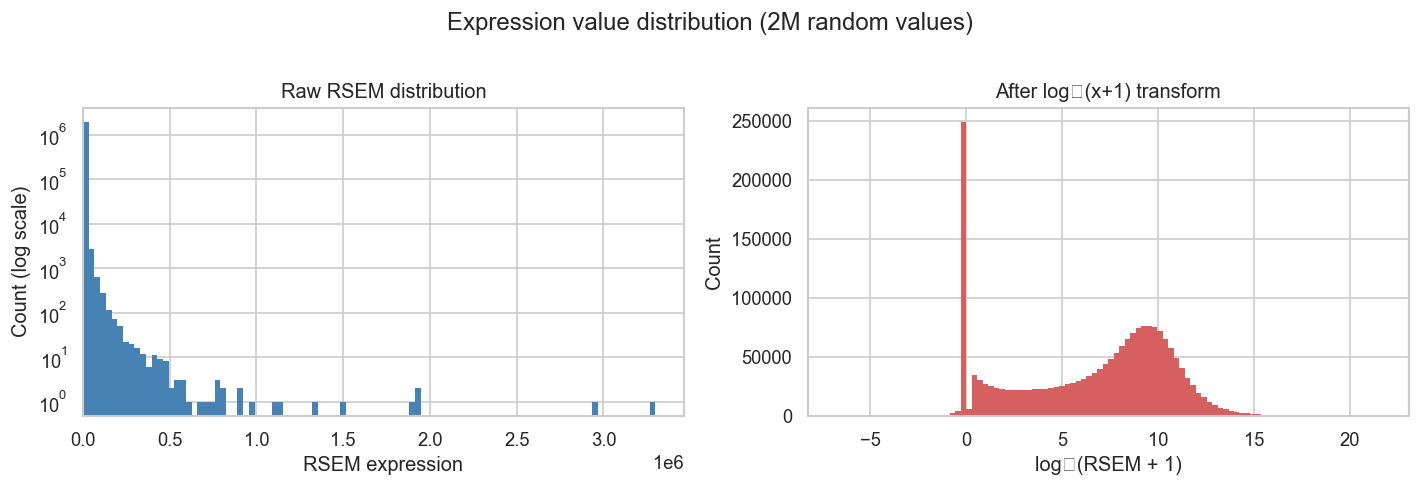


Log-transformed range: [nan, nan]


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw RSEM values
axes[0].hist(flat_sample, bins=100, color='steelblue', edgecolor='none', log=True)
axes[0].set_xlabel('RSEM expression')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Raw RSEM distribution')
axes[0].set_xlim(left=0)

# Log2(x + 1) transformed
log_sample = np.log2(flat_sample + 1)
axes[1].hist(log_sample, bins=100, color='#D65F5F', edgecolor='none')
axes[1].set_xlabel('log₂(RSEM + 1)')
axes[1].set_ylabel('Count')
axes[1].set_title('After log₂(x+1) transform')

plt.suptitle('Expression value distribution (2M random values)', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nLog-transformed range: [{log_sample.min():.2f}, {log_sample.max():.2f}]")

### 3b. Per-sample total expression (QC)

Outlier samples with unusually low total expression may represent failed sequencing runs.

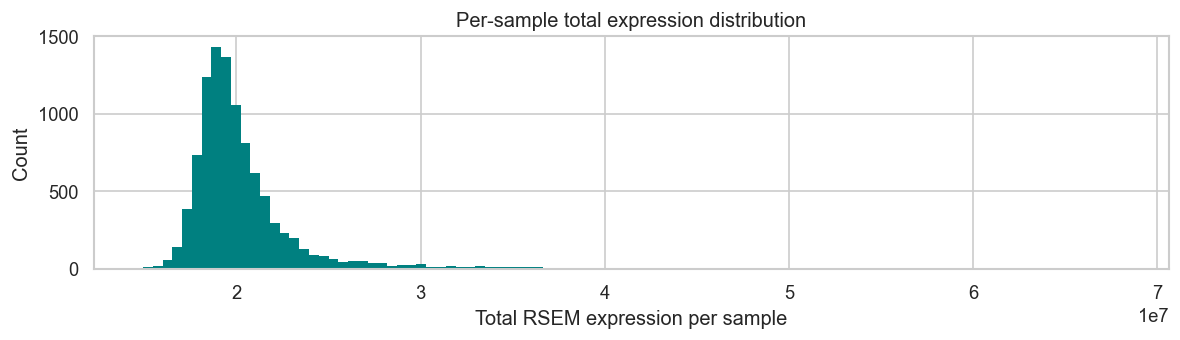

Samples with total < 1000: 0
Bottom 5 samples by total expression:
patient_id
TCGA-AB-2816    1.492399e+07
TCGA-AB-2901    1.503853e+07
TCGA-AB-2966    1.504468e+07
TCGA-AB-2840    1.509552e+07
TCGA-AB-2855    1.521843e+07


In [9]:
sample_totals = X.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(sample_totals, bins=100, color='teal', edgecolor='none')
ax.set_xlabel('Total RSEM expression per sample')
ax.set_ylabel('Count')
ax.set_title('Per-sample total expression distribution')
plt.tight_layout()
plt.show()

print(f"Samples with total < 1000: {(sample_totals < 1000).sum()}")
print(f"Bottom 5 samples by total expression:")
print(sample_totals.nsmallest(5).to_string())

### 3c. Per-gene mean expression

Many genes will have near-zero mean expression across all samples. These add noise without signal and will be removed in preprocessing.

Genes with mean RSEM == 0    : 220
Genes with mean RSEM  < 0.1  : 892
Genes with mean RSEM  < 1.0  : 1,733
Total genes                  : 20,501


/var/folders/bp/dy6w12yn1bgg5xmsdj1c8qg80000gn/T/ipykernel_93848/3881844054.py:13: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/elizabeth/opt/anaconda3/envs/tp53-predictor/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


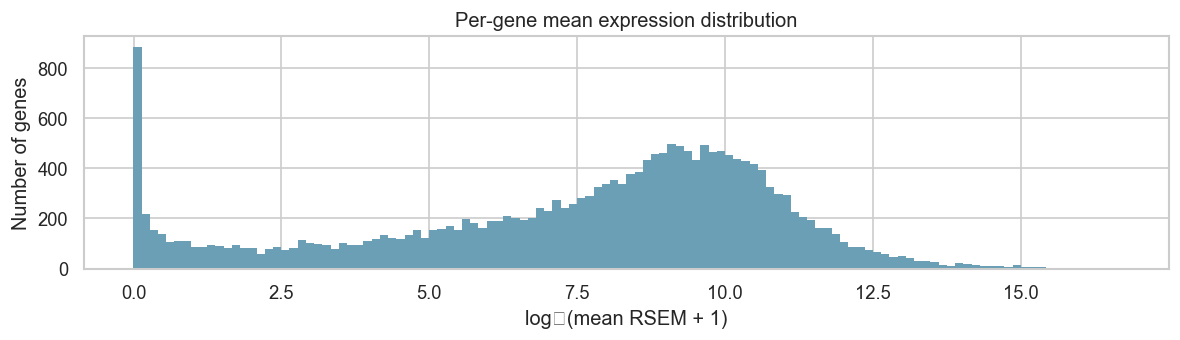

In [10]:
gene_means = X.mean(axis=0)

print(f"Genes with mean RSEM == 0    : {(gene_means == 0).sum():,}")
print(f"Genes with mean RSEM  < 0.1  : {(gene_means < 0.1).sum():,}")
print(f"Genes with mean RSEM  < 1.0  : {(gene_means < 1.0).sum():,}")
print(f"Total genes                  : {len(gene_means):,}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(np.log2(gene_means + 1), bins=120, color='#6A9FB5', edgecolor='none')
ax.set_xlabel('log₂(mean RSEM + 1)')
ax.set_ylabel('Number of genes')
ax.set_title('Per-gene mean expression distribution')
plt.tight_layout()
plt.show()

---

## 4. TP53 expression by mutation status and subtype

TP53 mRNA level is an interesting but non-obvious predictor of mutation status. Missense gain-of-function mutations often stabilise p53 protein (upregulating TP53 mRNA), while truncating mutations may show lower expression due to nonsense-mediated decay. Wild-type p53 is tightly regulated and shows intermediate expression.

We visualise TP53 expression:
1. WT vs Mutated (binary) — Mann-Whitney U test
2. Per mutation subtype — Kruskal-Wallis + pairwise Mann-Whitney U vs WT

In [ ]:
if 'TP53' not in X.columns:
    print("TP53 not found in expression columns.")
else:
    tp53_log = np.log2(X['TP53'].clip(lower=0) + 1)

    # ── 4a. WT vs Mutated violin + t-test ─────────────────────────────────
    wt_vals  = tp53_log[y_bin == 0].dropna()
    mut_vals = tp53_log[y_bin == 1].dropna()

    u_stat, p_val = stats.mannwhitneyu(wt_vals, mut_vals, alternative='two-sided')
    p_text = f"Mann-Whitney U p = {p_val:.2e}"

    plot_df_bin = pd.DataFrame({
        'log2(TP53+1)': tp53_log,
        'Status': y_bin.map({0: 'Wild-type', 1: 'Mutated'})
    })

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Violin
    sns.violinplot(data=plot_df_bin, x='Status', y='log2(TP53+1)',
                   palette={'Wild-type': '#4878CF', 'Mutated': '#D65F5F'},
                   inner='box', ax=axes[0])
    axes[0].set_title(f'TP53 expression: WT vs Mutated\n{p_text}', fontsize=10)
    axes[0].set_xlabel('')

    # Box with strip
    sns.boxplot(data=plot_df_bin, x='Status', y='log2(TP53+1)',
                palette={'Wild-type': '#4878CF', 'Mutated': '#D65F5F'},
                width=0.5, fliersize=1, ax=axes[1])
    axes[1].set_title(f'TP53 expression: WT vs Mutated\n{p_text}', fontsize=10)
    axes[1].set_xlabel('')

    # Significance bar
    y_max = tp53_log.max()
    for ax in axes:
        ax.annotate('', xy=(1, y_max + 0.2), xytext=(0, y_max + 0.2),
                    arrowprops=dict(arrowstyle='-', color='black', lw=1.5))
        sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
        ax.text(0.5, y_max + 0.35, sig, ha='center', fontsize=13)

    plt.tight_layout()
    plt.show()

    print("Median log2(TP53 RSEM+1) by group:")
    print(plot_df_bin.groupby('Status')['log2(TP53+1)'].median().to_string())
    print(f"\n{p_text}  (n_WT={len(wt_vals):,}, n_mut={len(mut_vals):,})")

    # ── 4b. Per mutation subtype — violin + Kruskal-Wallis ────────────────
    plot_classes = ['WT', 'Missense', 'Nonsense', 'Frameshift', 'Splice', 'InFrame']
    plot_df_mc = pd.DataFrame({
        'log2(TP53+1)': tp53_log,
        'Mutation class': y_class
    })
    plot_df_mc = plot_df_mc[plot_df_mc['Mutation class'].isin(plot_classes)].copy()

    # Kruskal-Wallis across all classes
    groups = [plot_df_mc.loc[plot_df_mc['Mutation class'] == c, 'log2(TP53+1)'].dropna().values
              for c in plot_classes]
    kw_stat, kw_p = stats.kruskal(*groups)

    fig, ax = plt.subplots(figsize=(12, 5))
    palette_mc = {c: class_palette.get(c, '#AAAAAA') for c in plot_classes}
    sns.violinplot(data=plot_df_mc, x='Mutation class', y='log2(TP53+1)',
                   order=plot_classes, palette=palette_mc, inner='box', ax=ax)

    # Pairwise Mann-Whitney vs WT with annotation
    wt_vals_mc = plot_df_mc.loc[plot_df_mc['Mutation class'] == 'WT', 'log2(TP53+1)'].dropna()
    y_top = plot_df_mc['log2(TP53+1)'].max() + 0.3
    for i, cls in enumerate(plot_classes[1:], start=1):
        cls_vals = plot_df_mc.loc[plot_df_mc['Mutation class'] == cls, 'log2(TP53+1)'].dropna()
        if len(cls_vals) < 5:
            continue
        _, pw_p = stats.mannwhitneyu(wt_vals_mc, cls_vals, alternative='two-sided')
        sig = '***' if pw_p < 0.001 else ('**' if pw_p < 0.01 else ('*' if pw_p < 0.05 else 'ns'))
        y_annot = y_top + (i - 1) * 0.15
        ax.annotate('', xy=(i, y_annot), xytext=(0, y_annot),
                    arrowprops=dict(arrowstyle='-', color='gray', lw=1))
        ax.text((0 + i) / 2, y_annot + 0.05, sig, ha='center', fontsize=9)

    ax.set_title(f'TP53 mRNA expression by mutation subtype\n'
                 f'Kruskal-Wallis p = {kw_p:.2e}  (pairwise annotations vs WT)')
    ax.set_xlabel('')

    # Add sample counts
    for i, cls in enumerate(plot_classes):
        n = (plot_df_mc['Mutation class'] == cls).sum()
        ax.text(i, plot_df_mc['log2(TP53+1)'].min() - 0.3, f'n={n}',
                ha='center', fontsize=8, color='gray')

    plt.tight_layout()
    plt.show()

    print("\nMedian log2(TP53+1) by mutation subtype:")
    print(plot_df_mc.groupby('Mutation class')['log2(TP53+1)']
          .median().reindex(plot_classes).round(3).to_string())

---

## 5. Missing values heatmap

Check whether missing values cluster in any specific region of the matrix.

In [12]:
nan_per_gene = X.isnull().sum(axis=0)
nan_per_sample = X.isnull().sum(axis=1)

print(f"Genes with ≥1 NaN: {(nan_per_gene > 0).sum():,} / {len(nan_per_gene):,}")
print(f"Samples with ≥1 NaN: {(nan_per_sample > 0).sum():,} / {len(nan_per_sample):,}")

if nan_per_gene.sum() > 0:
    # Show top genes by missingness
    print("\nTop 10 genes by NaN count:")
    print(nan_per_gene.nlargest(10).to_string())

Genes with ≥1 NaN: 3,338 / 20,501
Samples with ≥1 NaN: 1,690 / 9,875

Top 10 genes by NaN count:
ACCSL      1690
ACSM4      1690
ACTL9      1690
ACTRT2     1690
ADAD1      1690
ADAM3A     1690
AFM        1690
ANXA8L1    1690
ASB11      1690
ASB17      1690


---

## 6. PCA and UMAP

Dimensionality reduction on log-transformed expression to visualise sample clustering. We use the top 1,000 most variable genes for speed.

Colour scheme:
- All mutation classes shown (including WT)
- Second panel: rare classes only (Nonsense, Frameshift, Splice, InFrame) to check separability without Missense dominating the plot

In [ ]:
N_GENES_PCA = 1000
rng = np.random.default_rng(0)
gene_subset = rng.choice(gene_cols, size=min(N_GENES_PCA, len(gene_cols)), replace=False)

X_sub = np.log2(X[gene_subset].fillna(0).clip(lower=0).values + 1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sub)

pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio (first 5 PCs):")
for i, var in enumerate(pca.explained_variance_ratio_[:5]):
    print(f"  PC{i+1}: {var*100:.2f}%")
print(f"  Top-10 cumulative: {pca.explained_variance_ratio_[:10].sum()*100:.2f}%")

In [ ]:
# ── 6a. PCA — all mutation classes ────────────────────────────────────────
all_plot_classes = ['WT', 'Missense', 'Nonsense', 'Frameshift', 'Splice', 'InFrame']
class_order_plot = ['Missense', 'WT', 'Nonsense', 'Frameshift', 'Splice', 'InFrame']  # zorder: large → small

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: all classes
for cls in class_order_plot:
    mask = y_class == cls
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=class_palette.get(cls, '#AAAAAA'),
                    alpha=0.4, s=8, label=f'{cls} (n={mask.sum():,})', rasterized=True)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title('PCA — all mutation classes')
axes[0].legend(markerscale=2.5, fontsize=8, loc='upper right')

# Panel 2: rare classes only (Missense and WT hidden to show rare class separability)
rare_classes = ['WT', 'Nonsense', 'Frameshift', 'Splice', 'InFrame']
for cls in rare_classes:
    mask = y_class == cls
    alpha = 0.15 if cls == 'WT' else 0.7
    size  = 5    if cls == 'WT' else 15
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=class_palette.get(cls, '#AAAAAA'),
                    alpha=alpha, s=size, label=f'{cls} (n={mask.sum():,})', rasterized=True)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title('PCA — rare classes (WT faded, Missense hidden)')
axes[1].legend(markerscale=2.5, fontsize=8, loc='upper right')

plt.suptitle(f'PCA on {N_GENES_PCA} random genes (log₂-transformed, StandardScaled)', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ── 6b. UMAP — all mutation classes ──────────────────────────────────────
# UMAP captures non-linear structure that PCA misses; useful for seeing whether
# rare mutation subtypes form distinct neighbourhoods in expression space.
try:
    import umap

    # Use the PCA-reduced coordinates as input to UMAP (faster + denoised)
    reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.3,
                        random_state=42, verbose=False)
    # Subsample for speed if very large
    n_max = 5000
    rng2  = np.random.default_rng(1)
    if len(X_pca) > n_max:
        idx_sub = rng2.choice(len(X_pca), size=n_max, replace=False)
        X_umap_in = X_pca[idx_sub, :10]
        y_class_sub = y_class.iloc[idx_sub]
        print(f"UMAP: subsampled {n_max} / {len(X_pca)} samples for speed")
    else:
        X_umap_in = X_pca[:, :10]
        y_class_sub = y_class
        idx_sub = np.arange(len(X_pca))

    X_umap = reducer.fit_transform(X_umap_in)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Panel 1: all classes
    for cls in class_order_plot:
        mask = y_class_sub == cls
        axes[0].scatter(X_umap[mask, 0], X_umap[mask, 1],
                        c=class_palette.get(cls, '#AAAAAA'),
                        alpha=0.5, s=8, label=f'{cls} (n={mask.sum():,})', rasterized=True)
    axes[0].set_title('UMAP — all mutation classes')
    axes[0].legend(markerscale=2.5, fontsize=8, loc='best')
    axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')

    # Panel 2: rare classes with WT faded
    for cls in rare_classes:
        mask = y_class_sub == cls
        alpha = 0.1 if cls == 'WT' else 0.8
        size  = 5   if cls == 'WT' else 18
        axes[1].scatter(X_umap[mask, 0], X_umap[mask, 1],
                        c=class_palette.get(cls, '#AAAAAA'),
                        alpha=alpha, s=size, label=f'{cls} (n={mask.sum():,})', rasterized=True)
    axes[1].set_title('UMAP — rare classes (WT faded, Missense hidden)')
    axes[1].legend(markerscale=2.5, fontsize=8, loc='best')
    axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')

    plt.suptitle('UMAP on top-10 PCs (log₂-transformed expression)', y=1.01)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("umap-learn not installed. Install with: pip install umap-learn")
    print("Skipping UMAP visualisation.")

---

## 7. Coefficient of variation per gene

We inspect the CV distribution to motivate the low-variance gene filter applied in preprocessing.

CV 10th percentile threshold : 0.0590
Genes below threshold (to drop): 2,050
Genes to retain               : 18,451


/var/folders/bp/dy6w12yn1bgg5xmsdj1c8qg80000gn/T/ipykernel_93848/3829741254.py:17: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/elizabeth/opt/anaconda3/envs/tp53-predictor/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


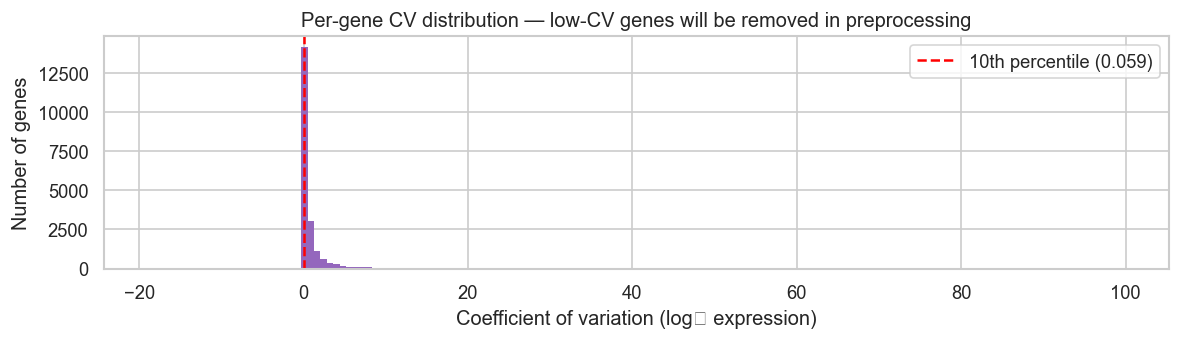

In [15]:
X_log = np.log2(X.fillna(0) + 1)

gene_cv = X_log.std(axis=0) / (X_log.mean(axis=0) + 1e-9)  # add epsilon to avoid div-by-zero

threshold_10 = gene_cv.quantile(0.10)
print(f"CV 10th percentile threshold : {threshold_10:.4f}")
print(f"Genes below threshold (to drop): {(gene_cv < threshold_10).sum():,}")
print(f"Genes to retain               : {(gene_cv >= threshold_10).sum():,}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(gene_cv, bins=150, color='#9467BD', edgecolor='none')
ax.axvline(threshold_10, color='red', linestyle='--', linewidth=1.5, label=f'10th percentile ({threshold_10:.3f})')
ax.set_xlabel('Coefficient of variation (log₂ expression)')
ax.set_ylabel('Number of genes')
ax.set_title('Per-gene CV distribution — low-CV genes will be removed in preprocessing')
ax.legend()
plt.tight_layout()
plt.show()

---

## 8. Key observations

> **Edit this cell** after running the notebook to record your findings.

### Expression data
- Raw RSEM values are right-skewed; log₂(x+1) transform gives a roughly bimodal distribution (unexpressed vs. expressed genes)
- Some genes have zero or near-zero expression across all samples → will be removed
- Per-sample total expression shows no obvious outlier clusters

### Labels
- Binary: moderate class imbalance (inspect exact counts above) — SMOTE or class weighting needed in modeling
- Multi-class: severe imbalance — Missense dominates; Frameshift and Splice are rare

### Missing values
- Inspect output of Section 5; if NaNs are few, fill with 0 is safe (unexpressed)

### PCA
- Whether mutated/WT clusters are visible in PC1-2 informs how linearly separable the problem is

### Preprocessing decisions motivated by EDA
1. **Log-transform**: confirmed by skewed raw distribution
2. **Zero-expression gene removal**: confirmed by `gene_means == 0` count
3. **CV filtering**: confirmed by wide CV distribution with many low-CV genes
4. **Class imbalance handling**: required for both tasks